In [1]:
!pip install -q diffusers transformers accelerate xformers safetensors \
               controlnet-aux Pillow tqdm opencv-python-headless

import torch
print("GPU:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9,1), "GB" if torch.cuda.is_available() else "")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 11.9 MB/s eta 0:00:00
GPU: True
GPU name: Tesla T4
VRAM: 15.6 GB


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted")

Mounted at /content/drive
✅ Google Drive mounted


In [3]:
# ═══════════════════════════════════════════════════
#   EDIT ONLY THIS CELL
# ═══════════════════════════════════════════════════

INPUT_DIR  = "/content/drive/MyDrive/ship_masts"         # your original images
OUTPUT_DIR = "/content/drive/MyDrive/ship_mast_dataset"  # where dataset saves

# ── How many variants per image ──────────────────
# Damaged  : 3 ControlNet  + 3 img2img  = 6 total
# Good     : 2 ControlNet  + 2 img2img  = 4 total
N_DAMAGED_CONTROLNET = 3
N_DAMAGED_IMG2IMG    = 3
N_GOOD_CONTROLNET    = 2
N_GOOD_IMG2IMG       = 2

# ── img2img strength ─────────────────────────────
# Good (img2img): very low — stay as close to original as possible
GOOD_IMG2IMG_STRENGTH_MIN    = 0.10
GOOD_IMG2IMG_STRENGTH_MAX    = 0.20

# Damaged (img2img): medium — change surface, preserve structure
DAMAGED_IMG2IMG_STRENGTH_MIN = 0.48
DAMAGED_IMG2IMG_STRENGTH_MAX = 0.65

# ── ControlNet strength ──────────────────────────
# conditioning_scale: how hard ControlNet enforces edges (0.0–2.0)
# strength: how much to deviate from source image (0.0–1.0)
CONTROLNET_CONDITIONING_SCALE = 1.0   # edge enforcement (higher = more faithful structure)
GOOD_CONTROLNET_STRENGTH      = 0.35  # low = stay close for good condition
DAMAGED_CONTROLNET_STRENGTH_MIN = 0.50
DAMAGED_CONTROLNET_STRENGTH_MAX = 0.70

# ── Canny edge thresholds for ControlNet ─────────
CANNY_LOW  = 80
CANNY_HIGH = 200

# ── Inference settings ───────────────────────────
NUM_STEPS      = 25
GUIDANCE_SCALE = 7.5

# ═══════════════════════════════════════════════════

import os
from pathlib import Path

os.makedirs(OUTPUT_DIR, exist_ok=True)
SUPPORTED_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

if os.path.exists(INPUT_DIR):
    imgs = [f for f in os.listdir(INPUT_DIR) if Path(f).suffix.lower() in SUPPORTED_EXT]
    total_per_image = (N_DAMAGED_CONTROLNET + N_DAMAGED_IMG2IMG +
                       N_GOOD_CONTROLNET    + N_GOOD_IMG2IMG)
    print(f"✅ Config ready")
    print(f"   Input dir      : {INPUT_DIR}")
    print(f"   Output dir     : {OUTPUT_DIR}")
    print(f"   Images found   : {len(imgs)}")
    print(f"   Per image breakdown:")
    print(f"     Damaged  → {N_DAMAGED_CONTROLNET} ControlNet  + {N_DAMAGED_IMG2IMG} img2img  = {N_DAMAGED_CONTROLNET+N_DAMAGED_IMG2IMG} damaged")
    print(f"     Good     → {N_GOOD_CONTROLNET} ControlNet  + {N_GOOD_IMG2IMG} img2img  = {N_GOOD_CONTROLNET+N_GOOD_IMG2IMG} good")
    print(f"     Total per image : {total_per_image} variants")
    print(f"   Grand total    : ~{len(imgs) * total_per_image} generated images")
else:
    print(f"⚠️  INPUT_DIR not found: {INPUT_DIR}")

✅ Config ready
   Input dir      : /content/drive/MyDrive/ship_masts
   Output dir     : /content/drive/MyDrive/ship_mast_dataset
   Images found   : 2
   Per image breakdown:
     Damaged  → 3 ControlNet  + 3 img2img  = 6 damaged
     Good     → 2 ControlNet  + 2 img2img  = 4 good
     Total per image : 10 variants
   Grand total    : ~20 generated images


In [4]:
# ═══════════════════════════════════════════════════
#   PROMPT LIBRARY
#   ControlNet and img2img use the same prompts
#   ControlNet enforces structure via edges,
#   img2img enforces it via low strength
# ═══════════════════════════════════════════════════

GOOD_PROMPTS = [
    "ship mast in excellent condition, clean polished metal, fresh grey paint, blue sky, photorealistic, 8k, maritime photography",
    "naval vessel communication mast pristine condition, calm sea background, bright sunlight, well-maintained rigging, sharp focus, photorealistic",
    "ship mast well maintained, no damage, new paintwork, port dockyard environment, overcast sky, professional maritime photography, realistic",
    "marine vessel mast good condition, all rigging intact and taut, clean structure, ocean background, photorealistic, high detail",
    "ship radar mast clean and fully operational, clear weather, no rust no damage, maritime photography, realistic sharp",
]

DAMAGE_PROMPTS = [
    # Corrosion
    "ship mast with severe rust and corrosion, orange brown rust patches spreading across metal surface, rust streaks dripping downward, photorealistic maritime damage",
    "ship mast with localized corrosion at welded joints and bolt holes, rust bloom spreading outward, heavy oxidation, realistic maritime weathering",
    # Paint failure
    "ship mast with heavy paint peeling and blistering, faded chalky grey surface, large patches of bare corroded metal exposed, photorealistic weathering damage",
    "ship mast with UV-damaged faded and chalking paint, dull discolored finish, surface degradation from sun exposure, realistic maritime damage",
    # Structural
    "ship mast with bent and deformed upper section, structural damage from storm impact, visibly warped and buckled metal, photorealistic",
    "ship mast with visible cracks at base joint and weld points, hairline fractures propagating through steel, realistic structural damage",
    # Rigging
    "ship mast with broken and frayed rigging cables dangling loose, snapped wire ropes hanging freely, storm damage, photorealistic maritime",
    "ship mast with tangled and twisted rigging wires, broken antenna bracket hanging off, cable failure damage, realistic maritime condition",
    # Environmental
    "ship mast with extreme saltwater erosion, white salt crystal deposits on all surfaces, heavy marine fouling and weathering, photorealistic",
    "ship mast covered with heavy accumulation of bird droppings, white staining across horizontal surfaces and crossbars, realistic degradation",
    # Impact
    "ship mast with impact dents and collision damage, sections of crushed and deformed metal, deep dents and scratches, photorealistic",
    "ship mast with burn marks and heat discoloration, carbon scoring from electrical fault or fire, scorch patterns on metal, photorealistic",
    # Staining
    "ship mast with heavy oil and grease staining, dark fluid streaks running down the entire structure, contamination from machinery, photorealistic",
]

NEGATIVE_PROMPT = (
    "cartoon, illustration, painting, anime, sketch, drawing, watermark, "
    "text, labels, annotation, blurry, low quality, overexposed, underexposed, "
    "completely destroyed, unrecognizable mast, unrealistic damage, CGI, "
    "3D render, artificial, fake, toy, miniature, indoor model"
)

print(f"✅ Prompts loaded")
print(f"   Good prompts   : {len(GOOD_PROMPTS)}")
print(f"   Damage prompts : {len(DAMAGE_PROMPTS)}")

✅ Prompts loaded
   Good prompts   : 5
   Damage prompts : 13


In [5]:
# ═══════════════════════════════════════════════════
#   LOAD PIPELINES
#   Pipeline A : SD img2img          (~4 GB download)
#   Pipeline B : SD + ControlNet Canny (~4.6 GB total)
#   Both share the same SD 1.5 weights — efficient memory use
# ═══════════════════════════════════════════════════

import torch
from diffusers import (
    StableDiffusionImg2ImgPipeline,
    StableDiffusionControlNetImg2ImgPipeline,
    ControlNetModel,
    UniPCMultistepScheduler,
)
from PIL import Image

SD_MODEL_ID         = "runwayml/stable-diffusion-v1-5"
CONTROLNET_MODEL_ID = "lllyasviel/sd-controlnet-canny"

# ── Load ControlNet model ──
print("Loading ControlNet model (canny)...")
controlnet = ControlNetModel.from_pretrained(
    CONTROLNET_MODEL_ID,
    torch_dtype=torch.float16
)

# ── Pipeline A: plain img2img ──
print("Loading SD img2img pipeline...")
pipe_img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
    SD_MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe_img2img.scheduler = UniPCMultistepScheduler.from_config(pipe_img2img.scheduler.config)
pipe_img2img = pipe_img2img.to("cuda")
pipe_img2img.enable_attention_slicing()
pipe_img2img.enable_xformers_memory_efficient_attention()
print("✅ img2img pipeline ready")

# ── Pipeline B: ControlNet img2img ──
print("Loading ControlNet img2img pipeline (reuses SD weights)...")
pipe_controlnet = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
    SD_MODEL_ID,
    controlnet=controlnet,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe_controlnet.scheduler = UniPCMultistepScheduler.from_config(pipe_controlnet.scheduler.config)
pipe_controlnet = pipe_controlnet.to("cuda")
pipe_controlnet.enable_attention_slicing()
pipe_controlnet.enable_xformers_memory_efficient_attention()
print("✅ ControlNet pipeline ready")

print(f"\n✅ Both pipelines loaded")
print(f"   VRAM used: {torch.cuda.memory_allocated()/1e9:.1f} GB / "
      f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading ControlNet model (canny)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

...

✅ img2img pipeline ready
Loading ControlNet img2img pipeline (reuses SD weights)...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ ControlNet pipeline ready

✅ Both pipelines loaded
   VRAM used: 5.1 GB / 15.6 GB


In [6]:
# ═══════════════════════════════════════════════════
#   CORE HELPER FUNCTIONS
# ═══════════════════════════════════════════════════

import cv2
import numpy as np
import random
import torch
from PIL import Image
from pathlib import Path


def resize_for_sd(img: Image.Image, target: int = 512) -> Image.Image:
    """
    Resize + center-crop to target x target (SD 1.5 optimal size).
    """
    w, h   = img.size
    scale  = target / min(w, h)
    new_w  = int(w * scale)
    new_h  = int(h * scale)
    img    = img.resize((new_w, new_h), Image.LANCZOS)
    left   = (new_w - target) // 2
    top    = (new_h - target) // 2
    return img.crop((left, top, left + target, top + target))


def make_canny_control_image(img: Image.Image,
                              low: int = CANNY_LOW,
                              high: int = CANNY_HIGH) -> Image.Image:
    """
    Extract Canny edges from a PIL image.
    Returns a 3-channel PIL image of edges (white lines on black).
    This is the 'control signal' that ControlNet uses to enforce structure.

    How it works:
      - Canny detects edges (structural outlines of the mast)
      - ControlNet uses these edges as a hard geometric constraint
      - So even if the prompt says 'add rust', the mast shape is preserved
    """
    img_np   = np.array(img.convert("RGB"))
    gray     = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    edges    = cv2.Canny(gray, low, high)
    edges_3ch = np.stack([edges] * 3, axis=-1)   # replicate to 3 channels
    return Image.fromarray(edges_3ch)


# ── Generation: plain img2img ──────────────────────

def generate_img2img(
    source_img : Image.Image,
    prompt     : str,
    strength   : float,
    seed       : int = None,
) -> Image.Image:
    """
    SD img2img — anchors output to source image via 'strength'.
    Low strength = stays close to input structure/colour.
    Used for: good variants (strength 0.10–0.20), damaged variants (0.48–0.65)
    """
    if seed is None:
        seed = random.randint(0, 2**31)

    generator = torch.Generator("cuda").manual_seed(seed)

    with torch.autocast("cuda"):
        result = pipe_img2img(
            prompt              = prompt,
            negative_prompt     = NEGATIVE_PROMPT,
            image               = source_img,
            strength            = strength,
            num_inference_steps = NUM_STEPS,
            guidance_scale      = GUIDANCE_SCALE,
            generator           = generator,
            num_images_per_prompt = 1,
        )
    return result.images[0]


# ── Generation: ControlNet img2img ─────────────────

def generate_controlnet(
    source_img           : Image.Image,
    control_img          : Image.Image,   # canny edge image
    prompt               : str,
    strength             : float,
    conditioning_scale   : float = CONTROLNET_CONDITIONING_SCALE,
    seed                 : int   = None,
) -> Image.Image:
    """
    ControlNet img2img — uses Canny edges to lock the mast structure.

    Two-level control:
      1. control_image (edges) → locks geometry / shape of the mast
      2. strength              → controls how much colour/texture can change
      3. prompt                → steers appearance (rust, clean paint, etc.)

    This combination gives the best structure preservation for damaged variants.
    """
    if seed is None:
        seed = random.randint(0, 2**31)

    generator = torch.Generator("cuda").manual_seed(seed)

    with torch.autocast("cuda"):
        result = pipe_controlnet(
            prompt                   = prompt,
            negative_prompt          = NEGATIVE_PROMPT,
            image                    = source_img,      # init image
            control_image            = control_img,     # edge map
            strength                 = strength,
            controlnet_conditioning_scale = conditioning_scale,
            num_inference_steps      = NUM_STEPS,
            guidance_scale           = GUIDANCE_SCALE,
            generator                = generator,
            num_images_per_prompt    = 1,
        )
    return result.images[0]


print("✅ Core functions ready")

✅ Core functions ready


In [7]:
# ═══════════════════════════════════════════════════
#   PER-IMAGE PROCESSING FUNCTION
#
#   For each source mast image generates:
#
#   GOOD CONDITION (4 total):
#     good_cn_01.jpg  ← ControlNet  (edge-locked, low strength)
#     good_cn_02.jpg  ← ControlNet
#     good_i2i_01.jpg ← img2img     (strength 0.10–0.20)
#     good_i2i_02.jpg ← img2img
#
#   DAMAGED (6 total):
#     damaged_cn_01.jpg  ← ControlNet  (edge-locked, medium strength)
#     damaged_cn_02.jpg  ← ControlNet
#     damaged_cn_03.jpg  ← ControlNet
#     damaged_i2i_01.jpg ← img2img     (strength 0.48–0.65)
#     damaged_i2i_02.jpg ← img2img
#     damaged_i2i_03.jpg ← img2img
# ═══════════════════════════════════════════════════

import torch
from pathlib import Path
import random


def process_one_mast(image_path: Path, image_id: str, output_dir: str):

    img_out = Path(output_dir) / image_id
    img_out.mkdir(parents=True, exist_ok=True)

    # ── Load & prepare source ──────────────────────
    try:
        src     = Image.open(image_path).convert("RGB")
        src_512 = resize_for_sd(src, target=512)
    except Exception as e:
        print(f"  ❌ Cannot open {image_path.name}: {e}")
        return

    # Save original
    src_512.save(img_out / "original.jpg", quality=95)

    # Pre-compute canny edge map once (reused for all ControlNet calls)
    control_img = make_canny_control_image(src_512, low=CANNY_LOW, high=CANNY_HIGH)
    control_img.save(img_out / "canny_edges.jpg", quality=90)   # save for reference

    # ════════════════════════════════════════════════
    #   GOOD — CONTROLNET  (2 images)
    # ════════════════════════════════════════════════
    good_pool = random.sample(GOOD_PROMPTS, min(
        N_GOOD_CONTROLNET + N_GOOD_IMG2IMG, len(GOOD_PROMPTS)
    ))
    good_cn_prompts   = good_pool[:N_GOOD_CONTROLNET]
    good_i2i_prompts  = good_pool[N_GOOD_CONTROLNET:N_GOOD_CONTROLNET + N_GOOD_IMG2IMG]

    for i, prompt in enumerate(good_cn_prompts, 1):
        out_path = img_out / f"good_cn_{i:02d}.jpg"
        if out_path.exists():
            print(f"    ↩ Skipping {out_path.name}")
            continue
        seed = random.randint(0, 2**31)
        print(f"    🟢 [ControlNet] good_cn_{i:02d}  strength={GOOD_CONTROLNET_STRENGTH:.2f}  seed={seed}")
        try:
            img = generate_controlnet(
                source_img         = src_512,
                control_img        = control_img,
                prompt             = prompt,
                strength           = GOOD_CONTROLNET_STRENGTH,
                conditioning_scale = CONTROLNET_CONDITIONING_SCALE,
                seed               = seed,
            )
            img.save(out_path, quality=95)
        except Exception as e:
            print(f"    ❌ {out_path.name} failed: {e}")

    # ════════════════════════════════════════════════
    #   GOOD — IMG2IMG  (2 images, strength 0.10–0.20)
    # ════════════════════════════════════════════════
    for i, prompt in enumerate(good_i2i_prompts, 1):
        out_path = img_out / f"good_i2i_{i:02d}.jpg"
        if out_path.exists():
            print(f"    ↩ Skipping {out_path.name}")
            continue
        strength = random.uniform(GOOD_IMG2IMG_STRENGTH_MIN, GOOD_IMG2IMG_STRENGTH_MAX)
        seed     = random.randint(0, 2**31)
        print(f"    🟢 [img2img]    good_i2i_{i:02d}  strength={strength:.2f}  seed={seed}")
        try:
            img = generate_img2img(src_512, prompt, strength=strength, seed=seed)
            img.save(out_path, quality=95)
        except Exception as e:
            print(f"    ❌ {out_path.name} failed: {e}")

    # ════════════════════════════════════════════════
    #   DAMAGED — CONTROLNET  (3 images)
    # ════════════════════════════════════════════════
    damage_pool = random.sample(DAMAGE_PROMPTS, min(
        N_DAMAGED_CONTROLNET + N_DAMAGED_IMG2IMG, len(DAMAGE_PROMPTS)
    ))
    dmg_cn_prompts  = damage_pool[:N_DAMAGED_CONTROLNET]
    dmg_i2i_prompts = damage_pool[N_DAMAGED_CONTROLNET:N_DAMAGED_CONTROLNET + N_DAMAGED_IMG2IMG]

    for i, prompt in enumerate(dmg_cn_prompts, 1):
        out_path = img_out / f"damaged_cn_{i:02d}.jpg"
        if out_path.exists():
            print(f"    ↩ Skipping {out_path.name}")
            continue
        strength = random.uniform(DAMAGED_CONTROLNET_STRENGTH_MIN, DAMAGED_CONTROLNET_STRENGTH_MAX)
        seed     = random.randint(0, 2**31)
        print(f"    🔴 [ControlNet] damaged_cn_{i:02d}  strength={strength:.2f}  seed={seed}")
        try:
            img = generate_controlnet(
                source_img         = src_512,
                control_img        = control_img,
                prompt             = prompt,
                strength           = strength,
                conditioning_scale = CONTROLNET_CONDITIONING_SCALE,
                seed               = seed,
            )
            img.save(out_path, quality=95)
        except Exception as e:
            print(f"    ❌ {out_path.name} failed: {e}")

    # ════════════════════════════════════════════════
    #   DAMAGED — IMG2IMG  (3 images)
    # ════════════════════════════════════════════════
    for i, prompt in enumerate(dmg_i2i_prompts, 1):
        out_path = img_out / f"damaged_i2i_{i:02d}.jpg"
        if out_path.exists():
            print(f"    ↩ Skipping {out_path.name}")
            continue
        strength = random.uniform(DAMAGED_IMG2IMG_STRENGTH_MIN, DAMAGED_IMG2IMG_STRENGTH_MAX)
        seed     = random.randint(0, 2**31)
        print(f"    🔴 [img2img]    damaged_i2i_{i:02d}  strength={strength:.2f}  seed={seed}")
        try:
            img = generate_img2img(src_512, prompt, strength=strength, seed=seed)
            img.save(out_path, quality=95)
        except Exception as e:
            print(f"    ❌ {out_path.name} failed: {e}")

    total = len(list(img_out.glob("*.jpg")))
    print(f"  ✅ {image_id} done — {total} files saved (incl. original + edge map)\n")


print("✅ process_one_mast() ready")

✅ process_one_mast() ready


In [8]:
# ═══════════════════════════════════════════════════
#   RUN FULL BATCH — safe to re-run (resumes from last stop)
#   Expected time: ~90–120 min for 37 images on T4 GPU
# ═══════════════════════════════════════════════════

from tqdm.notebook import tqdm
import json

image_paths = sorted([
    p for p in Path(INPUT_DIR).iterdir()
    if p.suffix.lower() in SUPPORTED_EXT
])

if not image_paths:
    print(f"❌ No images found in {INPUT_DIR}")
else:
    expected_per_image = (
        1                          # original
        + N_GOOD_CONTROLNET        # good_cn_*.jpg
        + N_GOOD_IMG2IMG           # good_i2i_*.jpg
        + N_DAMAGED_CONTROLNET     # damaged_cn_*.jpg
        + N_DAMAGED_IMG2IMG        # damaged_i2i_*.jpg
        + 1                        # canny_edges.jpg
    )

    print(f"🚀 Starting batch")
    print(f"   Source images : {len(image_paths)}")
    print(f"   Per image     : {expected_per_image} files")
    print(f"   Grand total   : ~{len(image_paths) * expected_per_image} files")
    print(f"   Output        : {OUTPUT_DIR}")
    print("=" * 55)

    # Save config
    json.dump({
        "n_good_controlnet"   : N_GOOD_CONTROLNET,
        "n_good_img2img"      : N_GOOD_IMG2IMG,
        "n_damaged_controlnet": N_DAMAGED_CONTROLNET,
        "n_damaged_img2img"   : N_DAMAGED_IMG2IMG,
        "sd_model"            : SD_MODEL_ID,
        "controlnet_model"    : CONTROLNET_MODEL_ID,
        "total_source"        : len(image_paths),
    }, open(Path(OUTPUT_DIR) / "run_config.json", "w"), indent=2)

    for idx, img_path in enumerate(tqdm(image_paths, desc="Mast images")):
        image_id = f"mast_{idx+1:03d}"
        img_out  = Path(OUTPUT_DIR) / image_id

        # Resume check
        if img_out.exists():
            done = len(list(img_out.glob("*.jpg")))
            if done >= expected_per_image:
                print(f"[{idx+1:02d}/{len(image_paths)}] ↩ {image_id} complete ({done} files). Skipping.")
                continue

        print(f"\n[{idx+1:02d}/{len(image_paths)}] 📷  {img_path.name}  →  {image_id}")
        process_one_mast(img_path, image_id, OUTPUT_DIR)

        # Free GPU memory between images
        torch.cuda.empty_cache()

    print("\n" + "=" * 55)
    print("🎉 Batch complete!")

🚀 Starting batch
   Source images : 2
   Per image     : 12 files
   Grand total   : ~24 files
   Output        : /content/drive/MyDrive/ship_mast_dataset


Mast images:   0%|          | 0/2 [00:00<?, ?it/s]

[01/2] ↩ mast_001 complete (12 files). Skipping.
[02/2] ↩ mast_002 complete (12 files). Skipping.

🎉 Batch complete!


In [9]:
# ═══════════════════════════════════════════════════
#   DATASET STATISTICS
# ═══════════════════════════════════════════════════

mast_dirs = sorted([d for d in Path(OUTPUT_DIR).iterdir() if d.is_dir()])

t_orig = t_gcn = t_gi2i = t_dcn = t_di2i = 0
incomplete = []

for d in mast_dirs:
    orig  = len(list(d.glob("original.jpg")))
    gcn   = len(list(d.glob("good_cn_*.jpg")))
    gi2i  = len(list(d.glob("good_i2i_*.jpg")))
    dcn   = len(list(d.glob("damaged_cn_*.jpg")))
    di2i  = len(list(d.glob("damaged_i2i_*.jpg")))
    t_orig  += orig
    t_gcn   += gcn
    t_gi2i  += gi2i
    t_dcn   += dcn
    t_di2i  += di2i
    if (gcn < N_GOOD_CONTROLNET or gi2i < N_GOOD_IMG2IMG or
        dcn < N_DAMAGED_CONTROLNET or di2i < N_DAMAGED_IMG2IMG):
        incomplete.append((d.name, gcn, gi2i, dcn, di2i))

total = t_orig + t_gcn + t_gi2i + t_dcn + t_di2i

print("=" * 52)
print("  DATASET SUMMARY")
print("=" * 52)
print(f"  Mast groups              : {len(mast_dirs)}")
print(f"  Originals                : {t_orig}")
print(f"  Good   — ControlNet      : {t_gcn}  (target {len(mast_dirs)*N_GOOD_CONTROLNET})")
print(f"  Good   — img2img         : {t_gi2i}  (target {len(mast_dirs)*N_GOOD_IMG2IMG})")
print(f"  Damaged — ControlNet     : {t_dcn}  (target {len(mast_dirs)*N_DAMAGED_CONTROLNET})")
print(f"  Damaged — img2img        : {t_di2i}  (target {len(mast_dirs)*N_DAMAGED_IMG2IMG})")
print(f"  ─────────────────────────────────────")
print(f"  TOTAL images             : {total}")
print("=" * 52)

if incomplete:
    print(f"\n⚠️  {len(incomplete)} incomplete groups (re-run Cell 8 to fix):")
    print(f"   {'Name':<12} {'gcn':>5} {'gi2i':>6} {'dcn':>5} {'di2i':>6}")
    for name, gcn, gi2i, dcn, di2i in incomplete:
        print(f"   {name:<12} {gcn:>5}/{N_GOOD_CONTROLNET} {gi2i:>5}/{N_GOOD_IMG2IMG} {dcn:>5}/{N_DAMAGED_CONTROLNET} {di2i:>5}/{N_DAMAGED_IMG2IMG}")
else:
    print("✅ All groups complete!")

  DATASET SUMMARY
  Mast groups              : 2
  Originals                : 2
  Good   — ControlNet      : 0  (target 4)
  Good   — img2img         : 0  (target 4)
  Damaged — ControlNet     : 0  (target 6)
  Damaged — img2img        : 0  (target 6)
  ─────────────────────────────────────
  TOTAL images             : 2

⚠️  2 incomplete groups (re-run Cell 8 to fix):
   Name           gcn   gi2i   dcn   di2i
   mast_001         0/2     0/2     0/3     0/3
   mast_002         0/2     0/2     0/3     0/3


In [10]:
# ═══════════════════════════════════════════════════
#   SIAMESE PAIRS CSV
#   label 0 = similar    (original / good  ↔  any good)
#   label 1 = dissimilar (any good ↔ any damaged)
# ═══════════════════════════════════════════════════

import csv, random

mast_dirs = sorted([d for d in Path(OUTPUT_DIR).iterdir() if d.is_dir()])
pairs = []

for d in mast_dirs:
    original     = d / "original.jpg"
    good_imgs    = sorted(d.glob("good_cn_*.jpg")) + sorted(d.glob("good_i2i_*.jpg"))
    damaged_imgs = sorted(d.glob("damaged_cn_*.jpg")) + sorted(d.glob("damaged_i2i_*.jpg"))

    if not original.exists():
        continue

    # Similar (label 0): original ↔ each good
    for g in good_imgs:
        pairs.append((str(original), str(g), 0, "orig_vs_good"))

    # Similar (label 0): good ↔ good (within same mast)
    for i, g1 in enumerate(good_imgs):
        for g2 in good_imgs[i+1:]:
            pairs.append((str(g1), str(g2), 0, "good_vs_good"))

    # Dissimilar (label 1): original ↔ each damaged
    for dm in damaged_imgs:
        pairs.append((str(original), str(dm), 1, "orig_vs_damaged"))

    # Dissimilar (label 1): good ↔ damaged
    for g in good_imgs:
        for dm in damaged_imgs:
            pairs.append((str(g), str(dm), 1, "good_vs_damaged"))

random.shuffle(pairs)

csv_path = Path(OUTPUT_DIR) / "siamese_pairs.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["image_1", "image_2", "label", "pair_type"])
    writer.writerows(pairs)

similar    = sum(1 for p in pairs if p[2] == 0)
dissimilar = sum(1 for p in pairs if p[2] == 1)
ratio = similar / max(dissimilar, 1)

print(f"✅ Siamese pairs CSV → {csv_path}")
print(f"   Total pairs        : {len(pairs)}")
print(f"   Similar   (label 0): {similar}")
print(f"   Dissimilar(label 1): {dissimilar}")
print(f"   Balance ratio      : {ratio:.2f}  (1.0 = perfect balance)")
if ratio < 0.5:
    print("   ⚠️  Too few similar pairs. Consider good_vs_good augmentation.")
elif ratio > 2.0:
    print("   ⚠️  Too few dissimilar pairs. Consider adding more damage types.")

✅ Siamese pairs CSV → /content/drive/MyDrive/ship_mast_dataset/siamese_pairs.csv
   Total pairs        : 0
   Similar   (label 0): 0
   Dissimilar(label 1): 0
   Balance ratio      : 0.00  (1.0 = perfect balance)
   ⚠️  Too few similar pairs. Consider good_vs_good augmentation.


/tmp/ipykernel_3088/3087838579.py:52: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3088/3087838579.py:52: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3088/3087838579.py:52: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3088/3087838579.py:54: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches="tight")
/tmp/ipykernel_3088/3087838579.py:54: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches="tight")
/tmp/ipykernel_3088/3087838579.py:54: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=100, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/

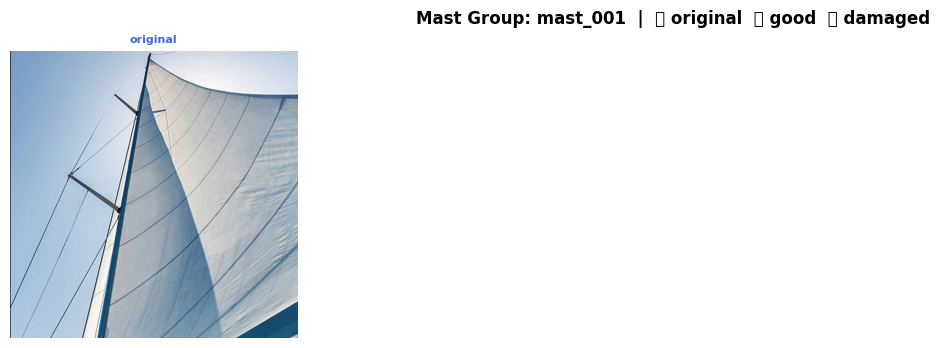

Preview saved → /content/drive/MyDrive/ship_mast_dataset/mast_001_preview.jpg


In [11]:
# ═══════════════════════════════════════════════════
#   VISUAL PREVIEW — shows all variants for one mast
#   Change mast_id below to inspect any group
# ═══════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

mast_id = "mast_001"   # ← change this

mast_dir = Path(OUTPUT_DIR) / mast_id

sections = {
    "original"  : [mast_dir / "original.jpg"],
    "good (CN)" : sorted(mast_dir.glob("good_cn_*.jpg")),
    "good (i2i)": sorted(mast_dir.glob("good_i2i_*.jpg")),
    "damaged (CN)" : sorted(mast_dir.glob("damaged_cn_*.jpg")),
    "damaged (i2i)": sorted(mast_dir.glob("damaged_i2i_*.jpg")),
}

all_imgs    = []
all_labels  = []
all_colours = []

for section_name, paths in sections.items():
    for p in paths:
        if p.exists():
            all_imgs.append(p)
            all_labels.append(p.stem)
            if "damaged" in section_name:
                all_colours.append("red")
            elif "good" in section_name:
                all_colours.append("green")
            else:
                all_colours.append("royalblue")

cols = 4
rows = (len(all_imgs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
axes = axes.flatten()

for ax, p, label, color in zip(axes, all_imgs, all_labels, all_colours):
    ax.imshow(mpimg.imread(str(p)))
    ax.set_title(label, color=color, fontsize=8, fontweight="bold")
    ax.axis("off")

for ax in axes[len(all_imgs):]:
    ax.set_visible(False)

plt.suptitle(f"Mast Group: {mast_id}  |  🔵 original  🟢 good  🔴 damaged",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_path = Path(OUTPUT_DIR) / f"{mast_id}_preview.jpg"
plt.savefig(save_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Preview saved → {save_path}")

In [13]:
# ═══════════════════════════════════════════════════
#   ZIP ENTIRE DATASET AND SAVE TO GOOGLE DRIVE
# ═══════════════════════════════════════════════════

import shutil, os

zip_name  = "ship_mast_dataset"
zip_local = f"/content/{zip_name}"

print(f"Zipping {OUTPUT_DIR} ...")
shutil.make_archive(zip_local, "zip", OUTPUT_DIR)

zip_file  = zip_local + ".zip"
size_mb   = os.path.getsize(zip_file) / (1024 * 1024)
print(f"✅ Zip created: {zip_file}  ({size_mb:.1f} MB)")

drive_zip = f"/content/drive/MyDrive/{zip_name}.zip"
shutil.copy(zip_file, drive_zip)
print(f"✅ Saved to Google Drive: {drive_zip}")

Zipping /content/drive/MyDrive/ship_mast_dataset ...
✅ Zip created: /content/ship_mast_dataset.zip  (2.6 MB)
✅ Saved to Google Drive: /content/drive/MyDrive/ship_mast_dataset.zip
